In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [28]:
#Prunible linear layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Learnable gate scores
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

In [29]:
#CNN +Prunable model
class PrunableCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(64 * 8 * 8, 256)
        self.relu = nn.ReLU()
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [30]:
#Dataset
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [32]:
#Training function
def train(model, lambda_sparse, epochs=15):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_sparse * sp_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.2f}")

    return model

In [33]:
#Evaluation(Accuracy+Sparsity)
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [34]:
#Sparsity Calculation
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total

In [35]:
#Run experiments
lambdas = [1e-5, 1e-4, 1e-3]
results = []

for lam in lambdas:
    print(f"\n🔥 Training with λ = {lam}")

    model = PrunableCNN().to(device)
    train(model, lam, epochs=15)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))

    print(f"✅ Accuracy: {acc:.2f}%")
    print(f"✅ Sparsity: {sparsity:.2f}%")


🔥 Training with λ = 1e-05
Epoch 1/15 | Loss: 2560.58
Epoch 2/15 | Loss: 2177.75
Epoch 3/15 | Loss: 1883.75
Epoch 4/15 | Loss: 1639.92
Epoch 5/15 | Loss: 1444.25
Epoch 6/15 | Loss: 1292.69
Epoch 7/15 | Loss: 1167.72
Epoch 8/15 | Loss: 1070.10
Epoch 9/15 | Loss: 990.48
Epoch 10/15 | Loss: 925.14
Epoch 11/15 | Loss: 868.31
Epoch 12/15 | Loss: 819.91
Epoch 13/15 | Loss: 780.08
Epoch 14/15 | Loss: 744.59
Epoch 15/15 | Loss: 713.45
✅ Accuracy: 74.64%
✅ Sparsity: 6.18%

🔥 Training with λ = 0.0001
Epoch 1/15 | Loss: 19568.04
Epoch 2/15 | Loss: 16257.15
Epoch 3/15 | Loss: 13279.71
Epoch 4/15 | Loss: 10712.56
Epoch 5/15 | Loss: 8609.16
Epoch 6/15 | Loss: 6948.95
Epoch 7/15 | Loss: 5669.93
Epoch 8/15 | Loss: 4684.93
Epoch 9/15 | Loss: 3926.78
Epoch 10/15 | Loss: 3336.04
Epoch 11/15 | Loss: 2870.55
Epoch 12/15 | Loss: 2495.77
Epoch 13/15 | Loss: 2195.59
Epoch 14/15 | Loss: 1949.36
Epoch 15/15 | Loss: 1744.82
✅ Accuracy: 72.94%
✅ Sparsity: 10.64%

🔥 Training with λ = 0.001
Epoch 1/15 | Loss: 18978

In [36]:
#Result table
print("\nFINAL RESULTS")
print("Lambda | Accuracy | Sparsity")

for r in results:
    print(f"{r[0]} | {r[1]:.2f}% | {r[2]:.2f}%")


FINAL RESULTS
Lambda | Accuracy | Sparsity
1e-05 | 74.64% | 6.18%
0.0001 | 72.94% | 10.64%
0.001 | 71.20% | 13.45%


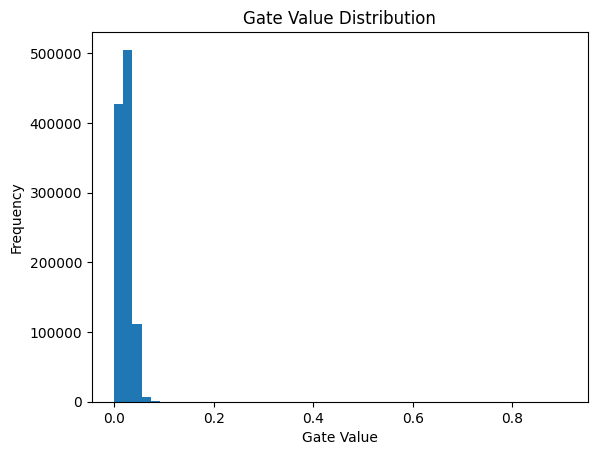

In [37]:
#Plot
all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()